In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plot_opts
plt.rcParams.update(plot_opts.params)

In [2]:
resolution = 0.02 #075
mesh_folder = f"output/reaction_distribution/20-20-80/{resolution}/"

In [3]:
def get_input_dir(Wa, Kr, gamma, n_procs=2):
    return os.path.join(mesh_folder, f'butler_volmer/0.001-{Wa}-{Kr}/{gamma}/{n_procs}')

In [4]:
# gamma = 0.01
results = []
Wa_test = [0.01, 1.0, 10.0, 50.0]
Kr_test = [0.05, 0.1, 1.0, 10.0, 50.0]
for Wa in Wa_test:
    for Kr in Kr_test:
        results_file_json_1 = os.path.join(get_input_dir(Wa, Kr, 0.1), "simulation.json")
        results_file_json_2 = os.path.join(get_input_dir(Wa, Kr, 0.01), "simulation.json")
        if os.path.isfile(results_file_json_1):
            results_file_json = results_file_json_1
        elif os.path.isfile(results_file_json_2):
            results_file_json = results_file_json_2
        else:
            continue
        if os.path.isfile(results_file_json):
            with open(results_file_json, "r") as fp:
                results_row = json.load(fp)
                if results_row.get("i (stdev) se/am [A/m2]") is not None:
                    results.append(results_row)
        else:
            print(f"{results_file_json} not found")

In [5]:
data = pd.DataFrame(results)
data.shape

(10, 32)

In [6]:
# Normalized stdev of current density at SE/AM interface
df_left = data[['Positive Wa', 'Kr', 'i (avg) left [A/m2]', 'i (stdev) left [A/m2]']]
df_se_am = data[['Positive Wa', 'Kr', 'i (avg) se/am [A/m2]', 'i (stdev) se/am [A/m2]']]
df_right = data[['Positive Wa', 'Kr', 'i (avg) right [A/m2]', 'i (stdev) right [A/m2]']]

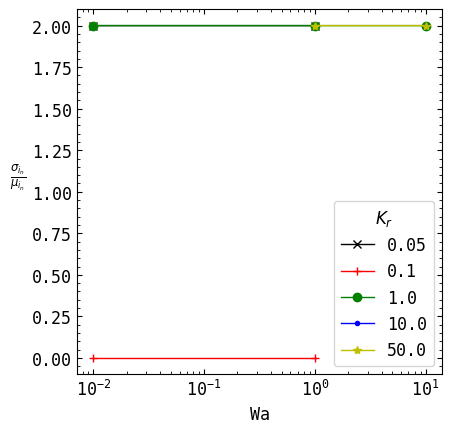

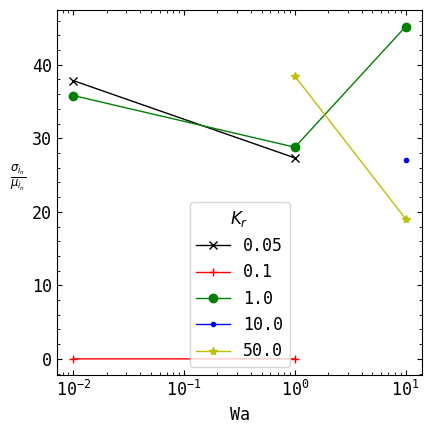

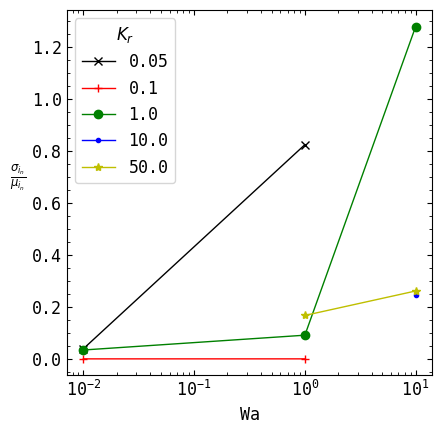

In [7]:
fig, ax = plt.subplots()
styles = ['kx-', 'r+-', 'go-', 'b.-', 'y*-']
for idx, Kr in enumerate(Kr_test):
    df_left_ = df_left[np.isclose(df_left['Kr'], Kr)]
    ax.semilogx(df_left_['Positive Wa'], df_left_['i (stdev) left [A/m2]'] / df_left_['i (avg) left [A/m2]'], styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$')
plt.tight_layout()

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_se_am_ = df_se_am[np.isclose(df_se_am['Kr'], Kr)]
    ax.semilogx(df_se_am_['Positive Wa'], df_se_am_['i (stdev) se/am [A/m2]'] / df_se_am_['i (avg) se/am [A/m2]'], styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$')
plt.tight_layout()

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_right_ = df_right[np.isclose(df_right['Kr'], Kr)]
    ax.semilogx(df_right_['Positive Wa'], df_right_['i (stdev) right [A/m2]'] / df_right_['i (avg) right [A/m2]'], styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$')
plt.tight_layout()

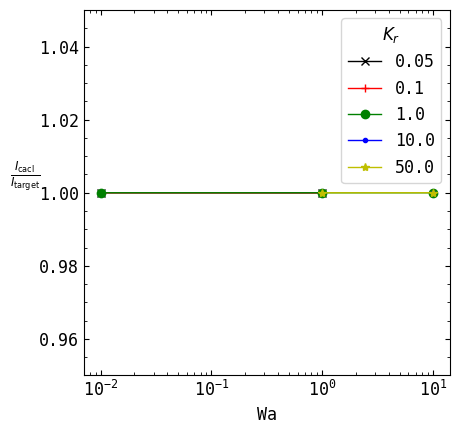

In [14]:
df_0 = data[['Positive Wa', 'Kr', 'I left [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_0_ = df_0[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_0_['Positive Wa'], np.abs(df_0_['I left [A]'] / df_0_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylim([0.95, 1.05])
ax.set_ylabel(r'$\frac{I_{\mathrm{cacl}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$')
plt.tight_layout()

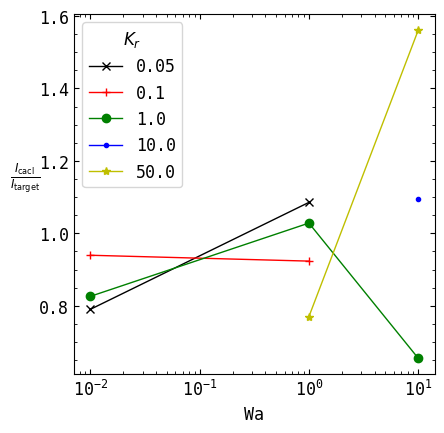

In [20]:
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I interface [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{I_{\mathrm{cacl}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$')
plt.tight_layout()

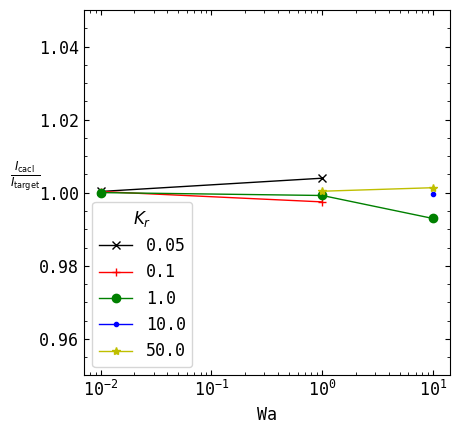

In [19]:
df_2 = data[['Positive Wa', 'Kr', 'I right [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_2_ = df_2[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_2_['Positive Wa'], np.abs(df_2_['I right [A]'] / df_2_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylim([0.95, 1.05])
ax.set_ylabel(r'$\frac{I_{\mathrm{cacl}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', loc='lower left')
plt.tight_layout()